In [2]:
import os
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F


In [3]:
df = pd.read_csv(f'BTCUSDT-15m-data.csv')
print(df.head())

             timestamp      open_time     open     high      low    close  \
0  2017-08-17 04:00:00  1502942400000  4261.48  4280.56  4261.48  4261.48   
1  2017-08-17 04:15:00  1502943300000  4261.48  4270.41  4261.32  4261.45   
2  2017-08-17 04:30:00  1502944200000  4280.00  4310.07  4267.99  4310.07   
3  2017-08-17 04:45:00  1502945100000  4310.07  4313.62  4291.37  4308.83   
4  2017-08-17 05:00:00  1502946000000  4308.83  4328.69  4304.31  4304.31   

      volume     close_time      quote_av  trades  tb_base_av   tb_quote_av  \
0   2.189061  1502943299999   9333.620962       9    0.489061   2089.104962   
1   9.119865  1502944199999  38891.133046      40    3.447113  14703.934995   
2  21.923552  1502945099999  94080.917568      58   20.421317  87620.977876   
3  13.948531  1502945999999  60060.466816      64   10.803012  46538.460109   
4   5.101153  1502946899999  22006.533111      44    3.496635  15093.783057   

   ignore  
0       0  
1       0  
2       0  
3       0  
4 

In [4]:
df.describe()

df.count()

,0
timestamp,276000
open_time,276000
open,276000
high,276000
low,276000
close,276000
volume,276000
close_time,276000
quote_av,276000
trades,276000


In [5]:
df.tail()

,timestamp,open_time,open,high,low,close,volume,close_time,quote_av,trades,tb_base_av,tb_quote_av,ignore
275995,2025-07-07 00:00:00,1751846400000,109203.85,109273.07,109103.19,109273.06,56.48447,1751847299999,6.166301e+06,26415,26.22332,2.862917e+06,0
275996,2025-07-07 00:15:00,1751847300000,109273.07,109288.02,108972.69,109004.81,75.36437,1751848199999,8.220317e+06,24191,33.56157,3.660548e+06,0
275997,2025-07-07 00:30:00,1751848200000,109004.81,109037.82,108829.17,108847.16,76.72080,1751849099999,8.357724e+06,21368,33.08997,3.605029e+06,0
275998,2025-07-07 00:45:00,1751849100000,108847.17,108922.00,108800.01,108823.07,45.06548,1751849999999,4.906468e+06,15579,22.76836,2.478881e+06,0
275999,2025-07-07 01:00:00,1751850000000,108823.07,108823.08,108679.75,108767.01,75.71845,1751850899999,8.232864e+06,22928,38.85713,4.224608e+06,0


In [6]:
print(df.isnull())
print(f'Counts how many missing values there are in each column: {df.isnull().sum()}')
print(f'Total missing values: {df.isnull().sum().sum()}')

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

#Training Phase

Splitting data to train/test sets

Practice same pattersn multiple times

Have access to answer key

problems known:
Overfitting
Underfitting

#Testing Phase

Face new Patterns

No access to asnwer key


In [7]:
train_end_idx = 240_000

df_train = df.iloc[:train_end_idx].copy()

df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

# Instead o preprocessing the data set first
# we split it and then preprocess
# this way we can ensure the test data do not leak into the training data

print(f'Length of training set: {len(df_train)}')
print(f'Length of testing set: {len(df_test)}')

Length of training set: 240000
Length of testing set: 36000


In [8]:
# what is a feature:
# a Mesurable piece of information that describe the data
# help the model to recognize patterns

#always pay attention to the shape of the data

def build_feature(opens, closes):
  fearure1 = (closes - opens) / opens

  features = np.stack([
      fearure1,
  ], axis=-1) # shape: (time_steps, num_features)

  num_features = features.shape[-1] # shape -1: means last dimentsion of the features array that correxpond to the n of features

  return features, num_features

In [9]:
def preprocessing_data(seq_len, df):
  m =len(df)

  opens = np.array(df['open'].values)
  closes = np.array(df['close'].values)

  features, num_features = build_feature(opens, closes)



  # calculate number of samples
  num_samples = m - seq_len

  #create storage for input & targets
  # x the input sequence
  # y the output/target
  X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
  Y = np.zeros([num_samples, num_features], dtype=np.float32)

  for i in range(num_samples):
    X[i] = features[i:i+seq_len]
    Y[i] = features[i+seq_len : i+seq_len+1]

  return X, Y, num_features

In [10]:
from re import X
# Sequence Lenght fot the inout sequence equivalent 1 day of 15m candles
seq_len = 96

# Processing data
X_train, Y_train, num_features = preprocessing_data(seq_len, df_train)
X_test, Y_test, num_features = preprocessing_data(seq_len, df_test)

m_train = X_train.shape[0]
m_test = X_test.shape[0]


print(f'Number of training samples (m_train): {m_train}')
print(f'Number of testing samples (m_test): {m_test}')
print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')

Number of training samples (m_train): 239904
Number of testing samples (m_test): 35904
X_train shape: (239904, 96, 1)
Y_train shape: (239904, 1)
X_test shape: (35904, 96, 1)
Y_test shape: (35904, 1)


In [11]:
# pytorch models can only work with tensors

# pytorch and tensorFlow

#what is a tensor: a similar to a numpy array, but it can be on a cpu

# pytorch works best with float 32

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("my device: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)


my device:  cpu


In [12]:
import numpy as np

#dot product caluculation
x = 82
W_h1 = 0.35
b_h1 = 52

W_h2 = 0.68
b_h2 = 12

W_out = [0.75, 0.46]
b_out = 37

h1 = x * W_h1 + b_h1
h2 = x * W_h2 + b_h2
H = [h1, h2]

Y_hat = np.dot(H, W_out) + b_out
print(f'Prediction: {Y_hat}')



Prediction: 128.6946


In [13]:
class Model(nn.Module):
    def __init__(self):
       super().__init__()

       #work station 1:
       # fc stand to fully connect layer typically linear
       self.fc1 = nn.Linear(in_features=seq_len * num_features, out_features = 20)

       self.act1 = nn.ReLU()

       #word station 2:
       self.fc2 = nn.Linear(in_features=20, out_features = 40)

       self.act2 = nn.ReLU()

       #Head Manager:
       self.fe_out = nn.Linear(in_features=40, out_features = num_features)


    def forward(self, x):
        # x shape: (batch_size, seq_len, num_features)
        x = x.reshape(-1, seq_len*num_features)

        # Pass to Workstation 1
        x = self.fc1(x)
        x = self.act1(x)

        # Pass to Workstation 2
        x = self.fc2(x)
        x = self.act2(x)

        # Get final output
        x = self.fe_out(x)

        return x

In [14]:
# Initialize model
model = Model()

# Transfer model to device
model.to(device)

# Initialize criterion (convention name for loss function)
# Mean Square Error
criterion = nn.MSELoss()

# Choose learning rate
lr = 1e-4

# Create optimizer
# Adam optmizer \ lr = learming rate
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Choose batch size
# 32 stable and nice speed
batch_size = 32

# Lists of train/test losses
train_losses = []
test_losses = []

# Set epoch
num_epochs = 200

In [15]:
def create_minibatches(X, Y, batch_size, shuffle=True):
    mini_batches = []
    m = len(X)

    if shuffle:
        permutation = list(np.random.permutation(m))
        X = X[permutation]
        Y = Y[permutation]

    num_batches = m // batch_size

    for k in range(num_batches):
        mb_X = X[k * batch_size : k * batch_size + batch_size]
        mb_Y = Y[k * batch_size : k * batch_size + batch_size]
        mb_pair = (mb_X, mb_Y)
        mini_batches.append(mb_pair)

    return mini_batches

Epoch: 0, train_losses: 0.00021410072773843738, test_losses: 7.566509339085314e-06, Duration: 0:00:09.905810


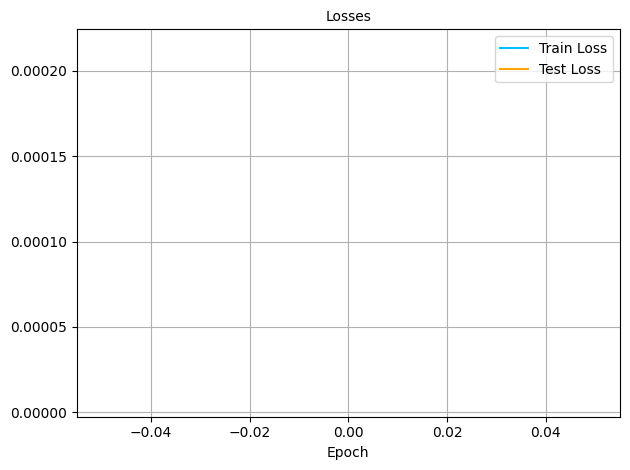

Epoch: 1, train_losses: 1.8596839055055503e-05, test_losses: 7.299688149942085e-06, Duration: 0:00:08.832268


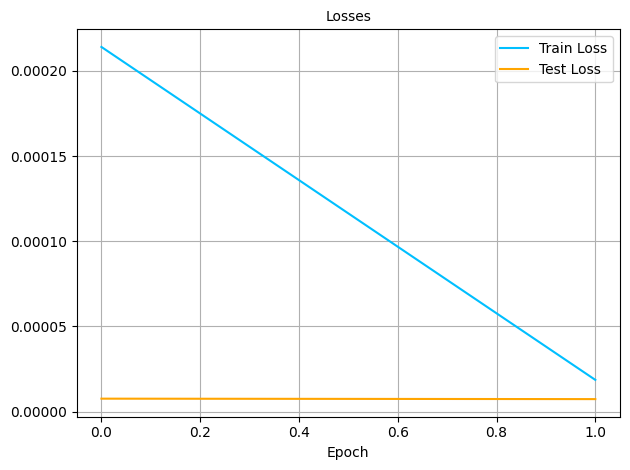

Epoch: 2, train_losses: 1.8559870856515806e-05, test_losses: 7.311305580515182e-06, Duration: 0:00:10.364755


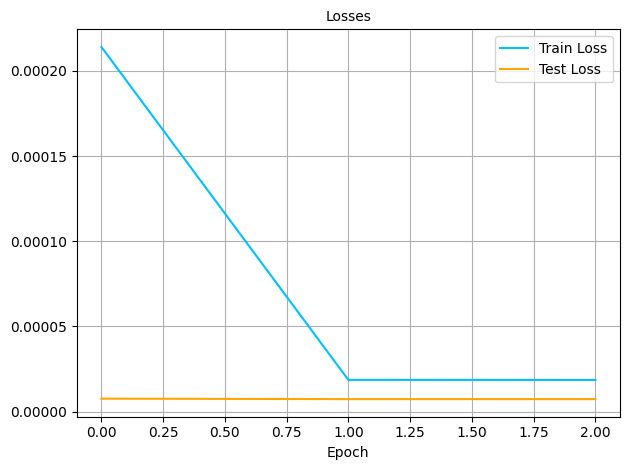

Epoch: 3, train_losses: 1.8527991178245966e-05, test_losses: 7.467919658665778e-06, Duration: 0:00:10.351521


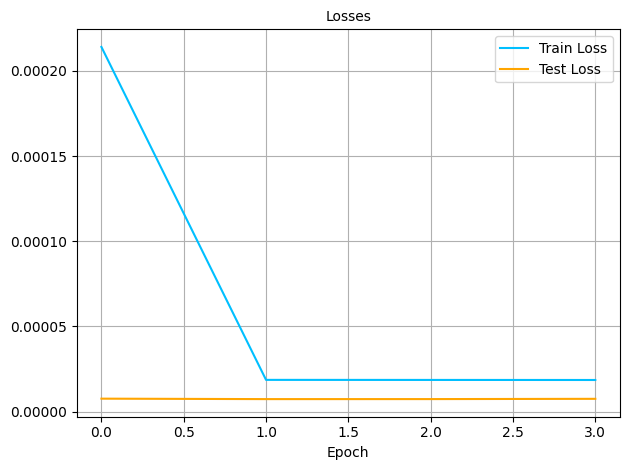

Epoch: 4, train_losses: 1.8502401503918132e-05, test_losses: 7.2764200922392774e-06, Duration: 0:00:09.827804


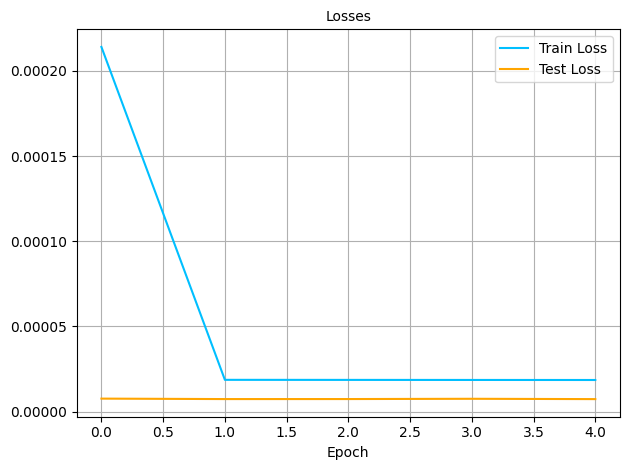

Epoch: 5, train_losses: 1.847088752878817e-05, test_losses: 7.278501925611636e-06, Duration: 0:00:10.496070


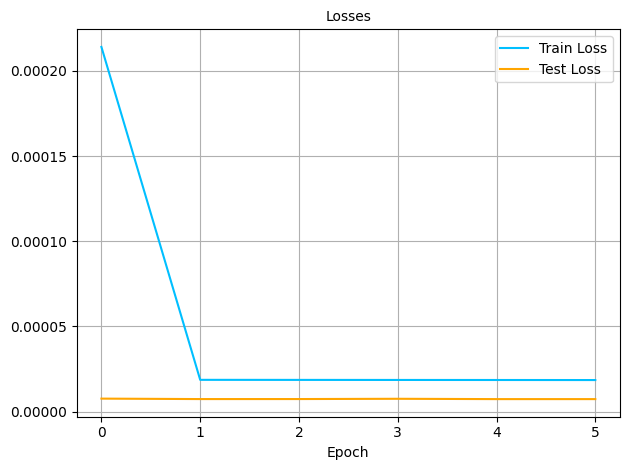

Epoch: 6, train_losses: 1.845272974443768e-05, test_losses: 7.546283541159937e-06, Duration: 0:00:10.906233


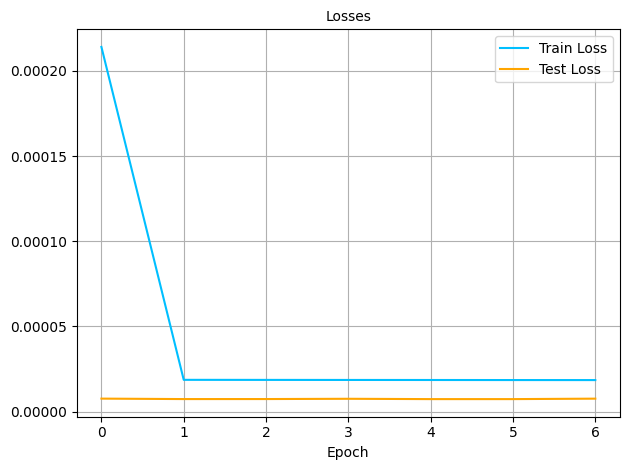

Epoch: 7, train_losses: 1.8372130563426196e-05, test_losses: 7.27692395230406e-06, Duration: 0:00:09.394443


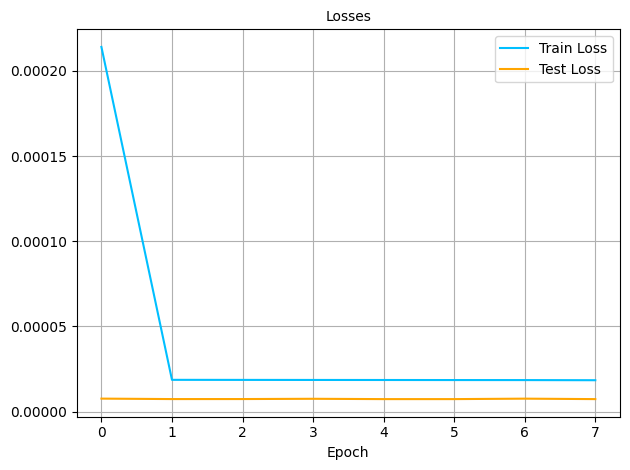

Epoch: 8, train_losses: 1.833628093888758e-05, test_losses: 7.281628768396331e-06, Duration: 0:00:10.219934


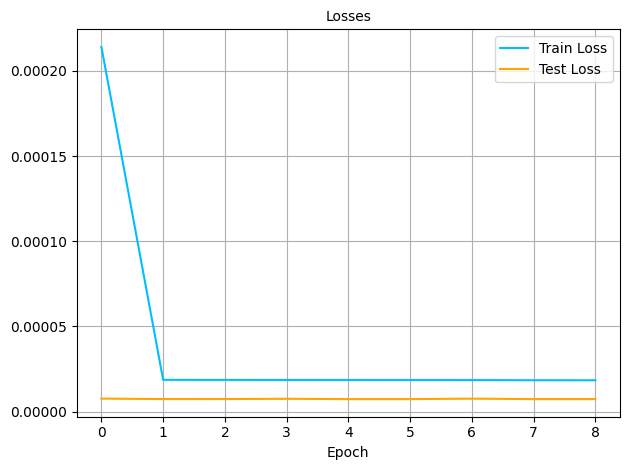

Epoch: 9, train_losses: 1.8301824577889872e-05, test_losses: 7.271218692039838e-06, Duration: 0:00:09.717890


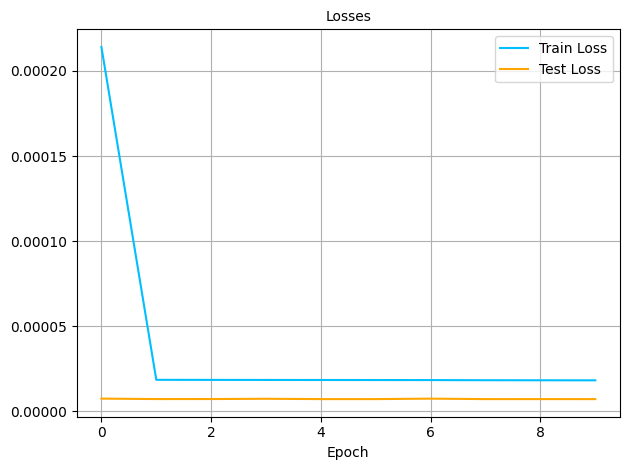

Epoch: 10, train_losses: 1.825156638180315e-05, test_losses: 7.442382866429398e-06, Duration: 0:00:09.695903


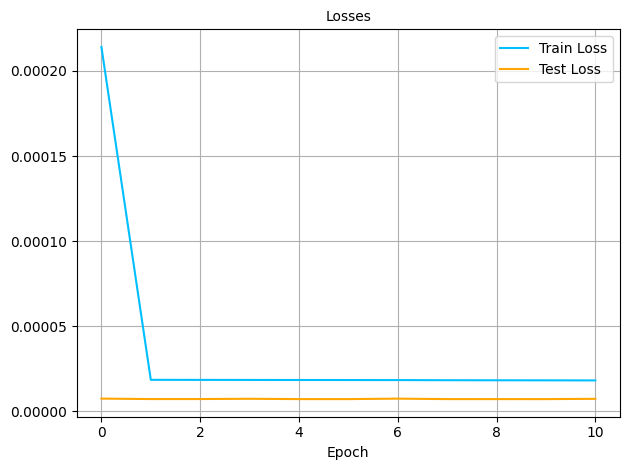

Epoch: 11, train_losses: 1.820887499979993e-05, test_losses: 7.2836496656236704e-06, Duration: 0:00:10.017370


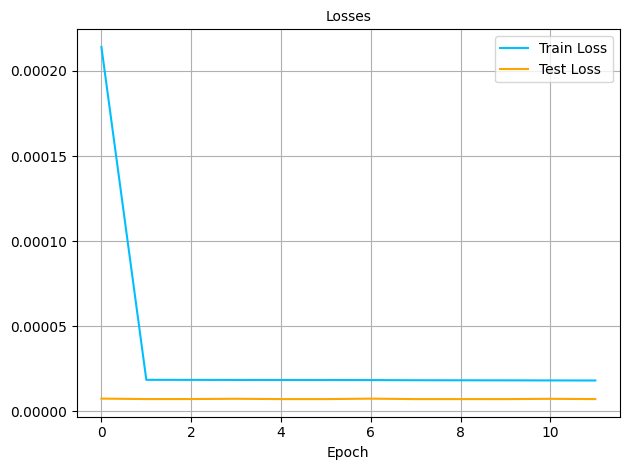

In [ ]:
for epoch in range(num_epochs):
    # Track duration
    dt0_epoch = datetime.now()

    # Create mini batches
    mini_batches = create_minibatches(X_train, Y_train, batch_size, shuffle=True)

    train_losses_batch = []

    for X_train_batch, Y_train_batch in mini_batches:
        # Set train mode
        model.train()

        # Reset the gradients
        optimizer.zero_grad()

        # Forward propagation
        Y_hat_train = model(X_train_batch) # Shape: (batch_size, num_features)

        # Calculate loss (train)
        train_loss = criterion(Y_hat_train, Y_train_batch)

        # Backprop
        train_loss.backward()

        # Update optimizer
        optimizer.step()

        # Keep track of training losses
        train_losses_batch.append(train_loss.item())

    # Predict on test data
    with torch.no_grad():

        # Set evaluation mode
        model.eval()

        # Forward propagation
        Y_pred_test = model(X_test)

        # Calculate test loss
        test_loss = criterion(Y_pred_test, Y_test)

    # Convert 'Y_pred_test' to numpy
    Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()

    train_losses.append(np.mean(train_losses_batch))
    test_losses.append(test_loss.item())

    print(f'Epoch: {epoch}, train_losses: {train_losses[-1]}, test_losses: {test_losses[-1]}, Duration: {datetime.now() - dt0_epoch}')

    # Plot Train Loss and Test Loss
    plt.title(f"Losses", fontsize=10)
    plt.plot(train_losses, label="Train Loss", color='deepskyblue')
    plt.plot(test_losses, label="Test Loss", color='orange')
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    # Display
    plt.tight_layout()
    plt.show()
    plt.close()